# 05 — Modeling (Baseline → Logistic → Tree)

This notebook trains models **leakage-free** using **purged walk-forward splits with embargo** and produces **out-of-sample scores** for backtesting.

**Inputs**
- `data/processed/financial_database_model_ready.parquet`

**Outputs**
- `data/processed/oos_scores.parquet` (out-of-sample rows only, with `baseline_score`, `ml_score`, `tree_score`)
- `results/folds.csv` (fold metadata)
- `results/model_metrics.csv` (IC + top-bottom spread on OOS)


In [3]:
# --- project setup (so notebooks/ can import src/) ---
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Optional: make plots look nicer
import matplotlib.pyplot as plt


In [4]:
import pandas as pd
import numpy as np

from src.modeling.splits import WalkForwardConfig, generate_purged_walk_forward_splits
from src.modeling.baseline import BaselineConfig, compute_rule_based_score
from src.modeling.models import (
    ModelIO,
    map_target_to_classes,
    build_logistic_pipeline,
    build_tree_model,
    fit_predict_oos_scores,
)
from src.modeling.metrics import mean_daily_spearman_ic, top_bottom_spread


In [ ]:
# --- paths ---
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "financial_database_model_ready.parquet"
OUT_OOS_PATH = PROJECT_ROOT / "data" / "processed" / "oos_scores.parquet"
FOLDS_PATH = PROJECT_ROOT / "results" / "folds.csv"
METRICS_PATH = PROJECT_ROOT / "results" / "model_metrics.csv"

# Ensure output dirs exist
(OUT_OOS_PATH.parent).mkdir(parents=True, exist_ok=True)
(FOLDS_PATH.parent).mkdir(parents=True, exist_ok=True)

DATA_PATH


In [6]:
# --- load data ---
df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

print("shape:", df.shape)
print("date range:", df["date"].min(), "→", df["date"].max())
print("tickers:", df["ticker"].nunique(), sorted(df["ticker"].unique().tolist()))
df.head()


shape: (27020, 53)
date range: 2015-01-02 00:00:00 → 2025-09-30 00:00:00
tickers: 10 ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'KO', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,...,leverage_bucket,is_profitable,is_high_growth,is_high_leverage,rsi_state,trend_state,fwd_ret_3m,fwd_ret_6m,fwd_ret_3_6m,target
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237553,212818400,NaN,NaN,NaN,...,mid,1,1,1,0,<NA>,0.169419,0.161855,0.165637,1
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,...,high,0,1,1,0,<NA>,0.222093,0.413328,0.317710,1
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,...,low,1,0,0,0,<NA>,0.027193,0.030347,0.028770,0
3,2015-01-02,105.050003,105.550003,104.129997,104.519997,76.955574,5753600,NaN,NaN,NaN,...,mid,1,0,0,0,<NA>,-0.044641,-0.046991,-0.045816,-1
4,2015-01-02,42.259998,42.400002,41.799999,42.139999,29.783411,9921100,NaN,NaN,NaN,...,high,1,0,1,0,<NA>,-0.014912,-0.049003,-0.031958,0


## 1) Configure split (purged walk-forward + embargo)

Key idea: labels use forward returns up to ~6 months, so we add an **embargo** before each test period to prevent overlap leakage.


In [7]:
# --- split configuration ---
# You can tweak these safely later, but start with something simple and defensible.
split_cfg = WalkForwardConfig(
    date_col="date",
    train_years=3,
    test_months=6,
    embargo_days=126,   # ~6 months
    min_train_days=252  # at least 1 year of trading days
)

splits_iter = generate_purged_walk_forward_splits(df, split_cfg)
splits = list(splits_iter)

len(splits), splits[0][2] if splits else None


(15,
 {'train_start': Timestamp('2015-01-02 00:00:00'),
  'train_end': Timestamp('2018-01-02 00:00:00'),
  'test_start': Timestamp('2018-05-08 00:00:00'),
  'test_end': Timestamp('2018-11-08 00:00:00'),
  'embargo_days': 126})

In [8]:
# Quick sanity: show fold date ranges
for i, (_, __, info) in enumerate(splits[:5]):
    print(i, info["train_start"].date(), info["train_end"].date(), "|", info["test_start"].date(), info["test_end"].date(), "embargo_days:", info["embargo_days"])


0 2015-01-02 2018-01-02 | 2018-05-08 2018-11-08 embargo_days: 126
1 2015-07-05 2018-07-05 | 2018-11-08 2019-05-08 embargo_days: 126
2 2016-01-02 2019-01-02 | 2019-05-08 2019-11-08 embargo_days: 126
3 2016-07-05 2019-07-05 | 2019-11-08 2020-05-08 embargo_days: 126
4 2017-01-03 2020-01-03 | 2020-05-08 2020-11-08 embargo_days: 126


## 2) Baseline rule-based score (no fitting)

Uses a few robust signals (quality + momentum) as a deterministic benchmark.


In [10]:
# --- baseline config (edit if you want, but keep it small) ---
baseline_cfg = BaselineConfig(
    date_col="date",
    score_col="baseline_score",
    quality_features=["roe", "roa", "net_margin"],
    momentum_features=["trend_state", "ret_21d"],
    quality_weight=0.5,
    momentum_weight=0.5,
)

df = compute_rule_based_score(df, baseline_cfg)

df[["date","ticker","baseline_score"]].tail()


,date,ticker,baseline_score
27015,2025-09-30,META,0.625000
27016,2025-09-30,MSFT,0.633333
27017,2025-09-30,NVDA,0.758333
27018,2025-09-30,TSLA,0.450000
27019,2025-09-30,XOM,0.350000


## 3) Prepare target for ML

Map `target` {-1,0,+1} → `y` {0,1,2}. This keeps the original target too.


In [11]:
io = ModelIO(
    date_col="date",
    ticker_col="ticker",
    target_col="target",
    y_col="y",
    ret_col_for_ic="fwd_ret_3_6m",  # for IC diagnostics only
)

df = map_target_to_classes(df, io)
splits = list(generate_purged_walk_forward_splits(df, split_cfg))
splits_for_models = [(tr, te, info) for tr, te, info in splits]

df[["target","y"]].drop_duplicates().sort_values("target")


,target,y
3,-1,0
2,0,1
0,1,2


## 4) Train Logistic Regression (OOS scores)

We compute **out-of-sample (OOS)** scores fold-by-fold.


In [12]:
# --- ML features (keep this modest at first) ---
FEATURES = [
    "roe", "roa", "net_margin",
    "debt_to_equity",
    "trend_state", "rsi_state",
    "ret_21d",
    "volatility_20d",
]

missing = [c for c in FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing FEATURES columns: {missing}")

logit = build_logistic_pipeline(random_state=42)

# Create per-fold (train,test) dataframes with baseline already computed + y present
splits_for_models = []
for train_df, test_df, info in splits:
    # Use the already-prepared df slice (train_df/test_df are already slices of df)
    splits_for_models.append((train_df, test_df, info))

oos_logit, folds_df = fit_predict_oos_scores(
    splits=splits_for_models,
    features=FEATURES,
    model=logit,
    io=io,
    score_col="ml_score",
)

oos_logit.head()


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,...,is_high_leverage,rsi_state,trend_state,fwd_ret_3m,fwd_ret_6m,fwd_ret_3_6m,target,baseline_score,y,ml_score
0,2018-05-09,46.637501,46.849998,46.305000,46.840000,44.057087,92844800,40.751158,39.093155,40.925670,...,1,0,1,0.110425,0.095608,0.103016,0,0.766667,1,0.268357
1,2018-05-09,80.000000,80.400002,79.599998,80.400002,80.400002,72746000,75.702280,61.202237,76.869318,...,1,0,1,0.173209,0.021648,0.097428,0,0.708333,1,0.107261
2,2018-05-09,53.205002,54.700001,53.105499,54.447498,54.039200,47160000,52.892081,51.379109,51.913964,...,0,0,1,0.158299,-0.017797,0.070251,0,0.500000,1,0.159111
3,2018-05-09,122.989998,124.050003,122.529999,123.510002,99.413055,6808600,103.577110,107.565120,101.582179,...,0,-1,0,0.069896,0.170630,0.120263,0,0.125000,1,-0.746794
4,2018-05-09,41.970001,42.230000,41.669998,41.779999,32.849724,9295200,34.126524,35.139237,33.751173,...,1,-1,0,0.114433,0.195999,0.155216,1,0.200000,2,-0.944355


## 5) Train Tree model (OOS scores)

Histogram Gradient Boosting (fast, non-linear).


In [13]:
tree = build_tree_model(random_state=42, max_depth=3, learning_rate=0.05, max_iter=300)

oos_tree, _ = fit_predict_oos_scores(
    splits=splits_for_models,
    features=FEATURES,
    model=tree,
    io=io,
    score_col="tree_score",
)

oos_tree.head()


,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,...,is_high_leverage,rsi_state,trend_state,fwd_ret_3m,fwd_ret_6m,fwd_ret_3_6m,target,baseline_score,y,tree_score
0,2018-05-09,46.637501,46.849998,46.305000,46.840000,44.057087,92844800,40.751158,39.093155,40.925670,...,1,0,1,0.110425,0.095608,0.103016,0,0.766667,1,-0.247694
1,2018-05-09,80.000000,80.400002,79.599998,80.400002,80.400002,72746000,75.702280,61.202237,76.869318,...,1,0,1,0.173209,0.021648,0.097428,0,0.708333,1,-0.543283
2,2018-05-09,53.205002,54.700001,53.105499,54.447498,54.039200,47160000,52.892081,51.379109,51.913964,...,0,0,1,0.158299,-0.017797,0.070251,0,0.500000,1,-0.107539
3,2018-05-09,122.989998,124.050003,122.529999,123.510002,99.413055,6808600,103.577110,107.565120,101.582179,...,0,-1,0,0.069896,0.170630,0.120263,0,0.125000,1,-0.156198
4,2018-05-09,41.970001,42.230000,41.669998,41.779999,32.849724,9295200,34.126524,35.139237,33.751173,...,1,-1,0,0.114433,0.195999,0.155216,1,0.200000,2,-0.106330


## 6) Merge OOS outputs + evaluate (IC + Top–Bottom Spread)

- IC uses `fwd_ret_3_6m` (forward returns) as a **diagnostic** of ranking quality.
- Backtesting later uses `ret_1d` (realized returns).


In [14]:
# Merge: they should have the same OOS rows (same dates/tickers) if splits are identical.
key = ["date", "ticker"]
oos = oos_logit.merge(oos_tree[key + ["tree_score"]], on=key, how="inner")

# Keep only columns needed for backtest & diagnostics
keep_cols = [
    "date", "ticker",
    "ret_1d", "ret_5d", "ret_21d",
    "fwd_ret_3_6m", "target",
    "baseline_score", "ml_score", "tree_score",
]
missing_keep = [c for c in keep_cols if c not in oos.columns]
if missing_keep:
    raise ValueError(f"Missing required columns in OOS data: {missing_keep}")

oos = oos[keep_cols].sort_values(["date","ticker"]).reset_index(drop=True)
oos.head()


,date,ticker,ret_1d,ret_5d,ret_21d,fwd_ret_3_6m,target,baseline_score,ml_score,tree_score
0,2018-05-09,AAPL,0.004806,0.100236,0.094090,0.103016,0,0.766667,0.268357,-0.247694
1,2018-05-09,AMZN,-0.004843,0.006402,0.132503,0.097428,0,0.708333,0.107261,-0.543283
2,2018-05-09,GOOGL,-0.000821,0.017141,0.037742,0.070251,0,0.500000,0.159111,-0.107539
3,2018-05-09,JNJ,-0.007930,-0.026982,-0.053058,0.120263,0,0.125000,-0.746794,-0.156198
4,2018-05-09,KO,-0.007831,-0.018314,-0.046087,0.155216,1,0.200000,-0.944355,-0.106330


In [15]:
# --- Metrics on OOS ---
rows = []
for model_name, score_col in [
    ("baseline", "baseline_score"),
    ("logistic", "ml_score"),
    ("tree", "tree_score"),
]:
    ic = mean_daily_spearman_ic(oos, "date", score_col, "fwd_ret_3_6m")
    spread = top_bottom_spread(oos, "date", score_col, "fwd_ret_3_6m", q=0.3)
    rows.append({"model": model_name, "ic_mean": ic, "top_bottom_spread": spread})

metrics = pd.DataFrame(rows).sort_values("ic_mean", ascending=False)
metrics


/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/metrics.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = df.groupby(date_col).apply(lambda x: x[score_col].corr(x[ret_col], method="spearman"))
/Users/igordragone/projects/hybrid-stock-prediction-thesis/src/modeling/metrics.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic = df.groupby(date_col).apply(lambda x: x[score_col].corr(x[re

,model,ic_mean,top_bottom_spread
0,baseline,0.028204,-0.035300
2,tree,0.009601,0.004171
1,logistic,-0.044778,0.019875


## 7) Save artifacts

In [17]:
# Save fold metadata + model metrics
folds_df.to_csv(FOLDS_PATH, index=False)
metrics.to_csv(METRICS_PATH, index=False)

# Save OOS scores for backtesting notebook
oos.to_parquet(OUT_OOS_PATH, index=False)

print("Saved:")
print(" -", OUT_OOS_PATH)
print(" -", FOLDS_PATH)
print(" -", METRICS_PATH)


Saved:
 - /Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/oos_scores.parquet
 - /Users/igordragone/projects/hybrid-stock-prediction-thesis/results/folds.csv
 - /Users/igordragone/projects/hybrid-stock-prediction-thesis/results/model_metrics.csv


## 8) (Optional) Quick plots

These are just sanity visuals; the full report is in the backtest notebook.


/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_66048/58874811.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = df_in.groupby("date").apply(lambda x: x[score_col].corr(x["fwd_ret_3_6m"], method="spearman"))
/var/folders/s6/9f3nj5t50b1f2ytqq5m43b4r0000gn/T/ipykernel_66048/58874811.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ic_series = df_in.groupby("date").apply(lambda x: x[score_col

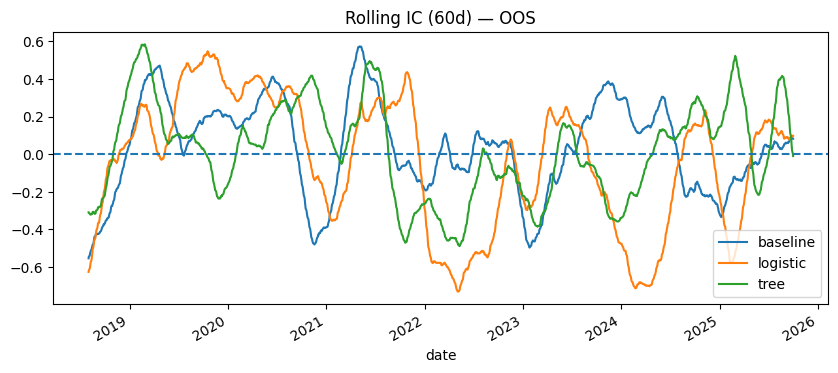

In [16]:
# Plot rolling IC for each model (diagnostic)
def rolling_ic(df_in, score_col, window=60):
    ic_series = df_in.groupby("date").apply(lambda x: x[score_col].corr(x["fwd_ret_3_6m"], method="spearman"))
    return ic_series.rolling(window).mean()

plt.figure(figsize=(10,4))
for name, col in [("baseline","baseline_score"), ("logistic","ml_score"), ("tree","tree_score")]:
    rolling_ic(oos, col, window=60).plot(label=name)
plt.axhline(0, linestyle="--")
plt.title("Rolling IC (60d) — OOS")
plt.legend()
plt.show()
